# Tree Based

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import (
     confusion_matrix,
     classification_report
)
from sklearn.tree import plot_tree

In [4]:
iris=load_iris(as_frame=True)
x=iris.data
y=iris.target
print("features:",x.head())
print("Class name:",iris.target_names)
print("Dataset shape:")
print(x.shape)
print(y.shape)
print("Class Distribution")
print(y.value_counts().sort_index())

features:    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
Class name: ['setosa' 'versicolor' 'virginica']
Dataset shape:
(150, 4)
(150,)
Class Distribution
target
0    50
1    50
2    50
Name: count, dtype: int64


In [5]:
X_train,X_test,y_train, y_test=train_test_split(
     x,y,
     test_size=0.20,
     random_state=42,
     stratify=y
)
print("Training Shape:",X_train.shape)
print("Testing shape",y_train.shape)

Training Shape: (120, 4)
Testing shape (120,)


In [6]:
full_tree=DecisionTreeClassifier(
     criterion="gini",
     random_state=42
)
full_tree.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [7]:
full_train_pred=full_tree.predict(X_train)
full_test_pred=full_tree.predict(X_test)
full_train_accuracy=accuracy_score(y_train,full_train_pred)
full_test_accuracy=accuracy_score(y_test,full_test_pred)
print("Full tree Training Accuracy",full_train_accuracy)
print("Full tree testing Accuracy",full_test_accuracy)
print("Full tree Depth:",full_tree.get_depth())
print("Full tree Leaves:",full_tree.get_n_leaves())

Full tree Training Accuracy 1.0
Full tree testing Accuracy 0.9333333333333333
Full tree Depth: 5
Full tree Leaves: 8


In [8]:
controlled_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)
controlled_tree.fit(
    X_train,
    y_train
)
tree_train_pred = controlled_tree.predict(
    X_train
)
tree_test_pred = controlled_tree.predict(
    X_test
)
tree_train_accuracy = accuracy_score(
    y_train,
    tree_train_pred
)
tree_test_accuracy = accuracy_score(
    y_test,
    tree_test_pred
)
print("Controlled Tree Training Accuracy:",tree_train_accuracy)
print("Controlled Tree Testing Accuracy:",tree_test_accuracy)
print("Controlled Tree Depth:",controlled_tree.get_depth())
print("Controlled Tree Leaves:",controlled_tree.get_n_leaves())

Controlled Tree Training Accuracy: 0.9833333333333333
Controlled Tree Testing Accuracy: 0.9666666666666667
Controlled Tree Depth: 3
Controlled Tree Leaves: 5


In [9]:
print("Confusion Matrix:")
print(confusion_matrix(y_test,tree_test_pred))
print("Classification Report:")
print(classification_report(
     y_test,
     tree_test_pred,
     target_names=iris.target_names,
     zero_division=0
))

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



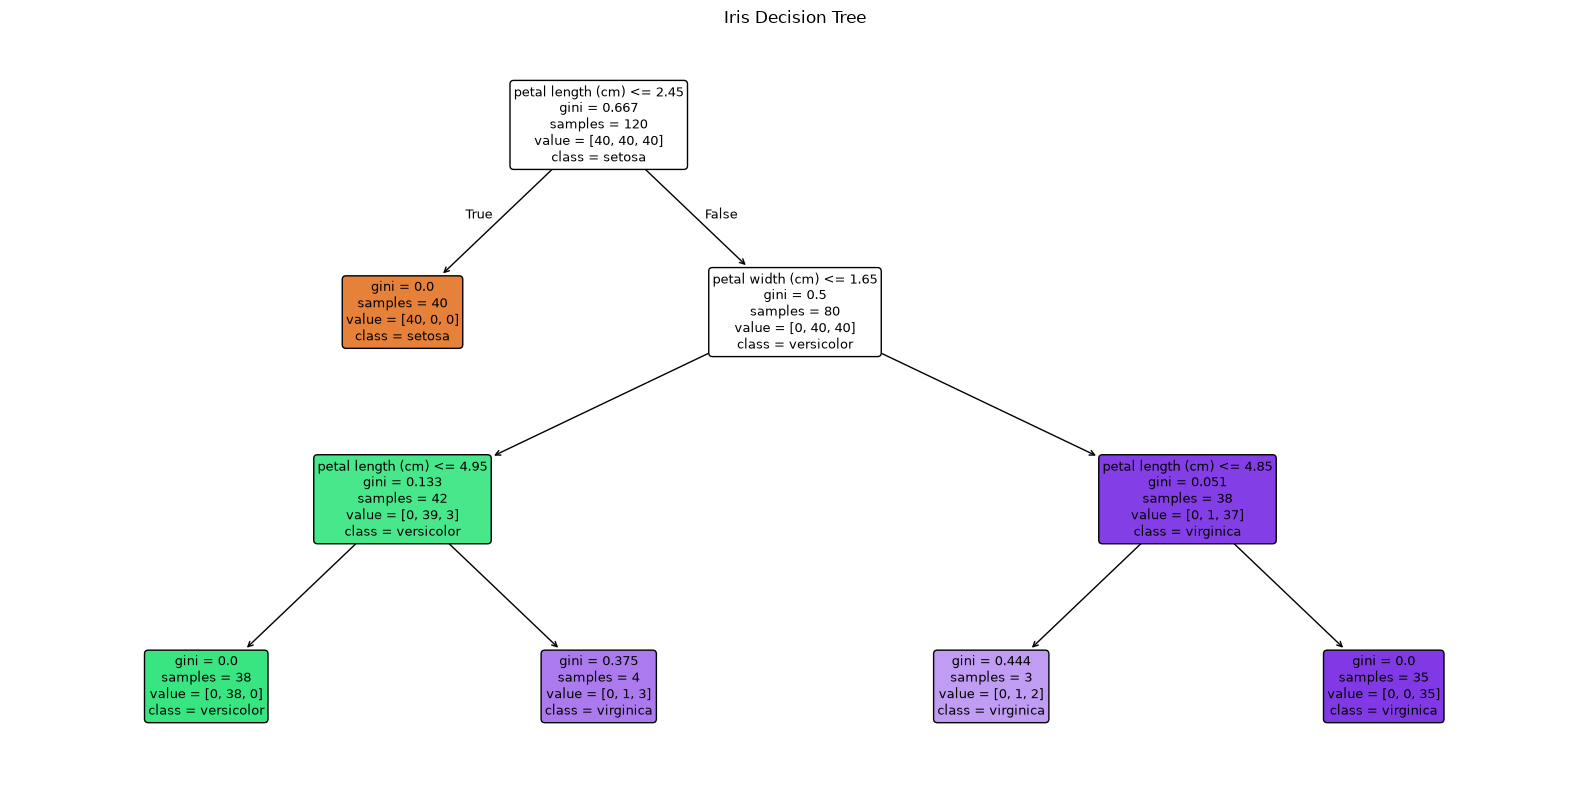

In [10]:
plt.figure(figsize=(16,8))
plot_tree(
     controlled_tree,
     feature_names=x.columns,
     class_names=iris.target_names,
     filled=True,
     rounded=True,
     fontsize=9
)
plt.title("Iris Decision Tree")
plt.tight_layout()
plt.show()


In [11]:
tree_imp=pd.DataFrame({
     "Feature":x.columns,
     "Importance":controlled_tree.feature_importances_
}).sort_values("Importance",ascending=False)
print(tree_imp)

             Feature  Importance
2  petal length (cm)    0.579077
3   petal width (cm)    0.420923
1   sepal width (cm)    0.000000
0  sepal length (cm)    0.000000


In [12]:
new_flower = pd.DataFrame(
    [[5.9, 3.0, 5.1, 1.8]],
    columns=x.columns
)
predicted_class = controlled_tree.predict(
    new_flower
)[0]
class_probabilities = (
    controlled_tree.predict_proba(
        new_flower
    )[0]
)
print(
    "Predicted Class:",
    iris.target_names[predicted_class]
)
for class_name, probability in zip(
    iris.target_names,
    class_probabilities
):
    print(
        f"{class_name}: {probability:.2%}"
    )

Predicted Class: virginica
setosa: 0.00%
versicolor: 0.00%
virginica: 100.00%


In [18]:
from sklearn.ensemble import RandomForestClassifier
forest_model=RandomForestClassifier(
     n_estimators=200,
     max_depth=5,
     min_samples_leaf=2,
     max_features="sqrt",
     bootstrap=True,
     random_state=42,
     n_jobs=1
)
forest_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total num

In [19]:
forest_train_pred = forest_model.predict(
    X_train
)
forest_test_pred = forest_model.predict(
    X_test
)
forest_train_accuracy = accuracy_score(
    y_train,
    forest_train_pred
)
forest_test_accuracy = accuracy_score(
    y_test,
    forest_test_pred
)
print("Forest Training Accuracy:",forest_train_accuracy)
print("Forest Testing Accuracy:",forest_test_accuracy)
print("\nForest Confusion Matrix:")
print(confusion_matrix(
        y_test,
        forest_test_pred
))
print("\nForest Classification Report:")
print(classification_report(
        y_test,
        forest_test_pred,
        target_names=iris.target_names,
        zero_division=0
))

Forest Training Accuracy: 0.9833333333333333
Forest Testing Accuracy: 0.9666666666666667

Forest Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Forest Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [21]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)
comparison = pd.DataFrame([
    {
        "Model": "Decision Tree",
        "Train Accuracy":
            tree_train_accuracy,
        "Test Accuracy":
            tree_test_accuracy,
        "Macro Precision":
            precision_score(
                y_test,
                tree_test_pred,
                average="macro",
                zero_division=0
            ),
        "Macro Recall":
            recall_score(
                y_test,
                tree_test_pred,
                average="macro",
                zero_division=0
            ),
        "Macro F1":
            f1_score(
                y_test,
                tree_test_pred,
                average="macro",
                zero_division=0
            )
    },
    {
        "Model": "Random Forest",
        "Train Accuracy":
            forest_train_accuracy,
        "Test Accuracy":
            forest_test_accuracy,
        "Macro Precision":
            precision_score(
                y_test,
                forest_test_pred,
                average="macro",
                zero_division=0
            ),
        "Macro Recall":
            recall_score(
                y_test,
                forest_test_pred,
                average="macro",
                zero_division=0
            ),
        "Macro F1":
            f1_score(
                y_test,
                forest_test_pred,
                average="macro",
                zero_division=0
            )
    }
])
comparison["Train-Test Gap"] = (
    comparison["Train Accuracy"]
    - comparison["Test Accuracy"]
)
comparison

,Model,Train Accuracy,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Train-Test Gap
0,Decision Tree,0.983333,0.966667,0.969697,0.966667,0.966583,0.016667
1,Random Forest,0.983333,0.966667,0.969697,0.966667,0.966583,0.016667


In [22]:
forest_imp=pd.DataFrame({
     "Feature":x.columns,
     "Importance":forest_model.feature_importances_
}).sort_values("Importance",ascending=False)
print(forest_imp)

             Feature  Importance
2  petal length (cm)    0.461856
3   petal width (cm)    0.417906
0  sepal length (cm)    0.110567
1   sepal width (cm)    0.009672


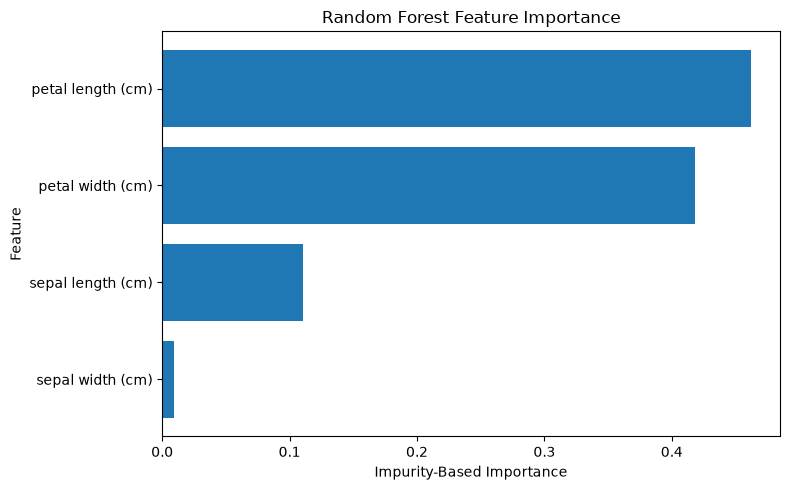

In [23]:
imp_plt=forest_imp.sort_values("Importance")
plt.figure(figsize=(8,5))
plt.barh(imp_plt["Feature"],imp_plt["Importance"])
plt.xlabel("Impurity-Based Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


In [24]:
oob_forest = RandomForestClassifier(
    n_estimators=200,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
oob_forest.fit(
    X_train,
    y_train
)
print(
    "OOB Score:",
    oob_forest.oob_score_
)

OOB Score: 0.95
